# Intrinsic Dimension Estimator Analysis
**d_true vs d_estimated** for CorrInt, MLE, TwoNN, and QuantDim across sample sizes n ∈ [500, 10 000].
Dataset: uniform hypercube `[0,1]^d` embedded in `R^50` via a random orthonormal map.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from id import CorrInt, MLE, TwoNN, TLE

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        True,
    "grid.color":       "#e0e0e0",
    "grid.linewidth":   0.7,
    "figure.dpi":       120,
})

In [2]:
def generate_dataset(n_samples: int, intrinsic_dim: int, ambient_dim: int, seed: int = 42) -> np.ndarray:
    """Uniform hypercube [0,1]^intrinsic_dim embedded in R^ambient_dim via a random orthonormal map."""
    rng = np.random.default_rng(seed)
    Z = rng.uniform(0, 1, size=(n_samples, intrinsic_dim))
    Q, _ = np.linalg.qr(rng.standard_normal((ambient_dim, intrinsic_dim)))
    return Z @ Q.T

AMBIENT_DIM  = 50
D_TRUE_VALS  = [2, 5, 10, 15, 20, 25]
N_SAMPLES    = [500, 1000, 2000, 5000, 10_000]

ESTIMATORS = {
    "CorrInt": CorrInt(),
    "MLE":     MLE(),
    "TwoNN":   TwoNN(),
    "TLE":     TLE(),
}

In [3]:
# results[est_name][n] = [d_est for each d in D_TRUE_VALS]
results = {name: {} for name in ESTIMATORS}

for est_name, est in ESTIMATORS.items():
    print(f"── {est_name} ──")
    for n in N_SAMPLES:
        d_ests = []
        for d in D_TRUE_VALS:
            X = generate_dataset(n_samples=n, intrinsic_dim=d, ambient_dim=AMBIENT_DIM, seed=42)
            d_ests.append(type(est)(**est.__dict__).fit(X).dimension_)
        results[est_name][n] = d_ests
        print(f"  n={n:>6,} done")

── CorrInt ──
  n=   500 done
  n= 1,000 done


  n= 2,000 done


  n= 5,000 done


  n=10,000 done
── MLE ──
  n=   500 done
  n= 1,000 done


  n= 2,000 done


...

  n=   500 done


  n= 1,000 done


  n= 2,000 done


  n= 5,000 done


  n=10,000 done


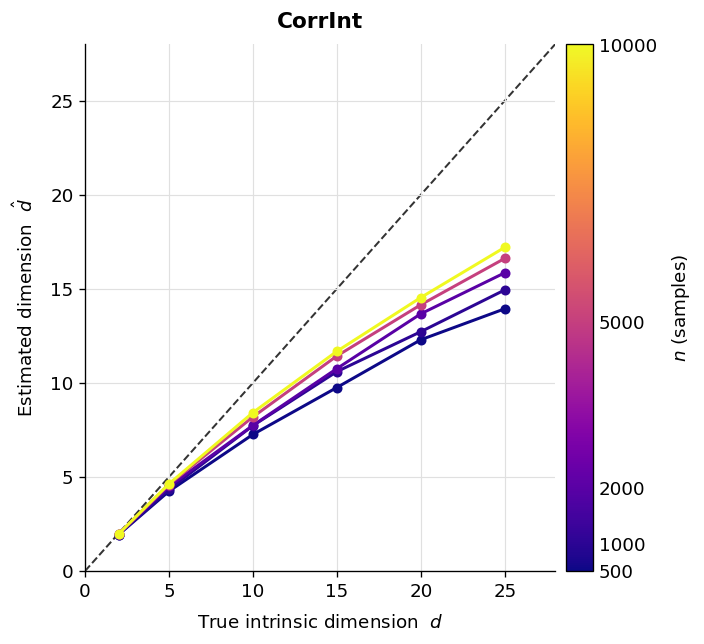

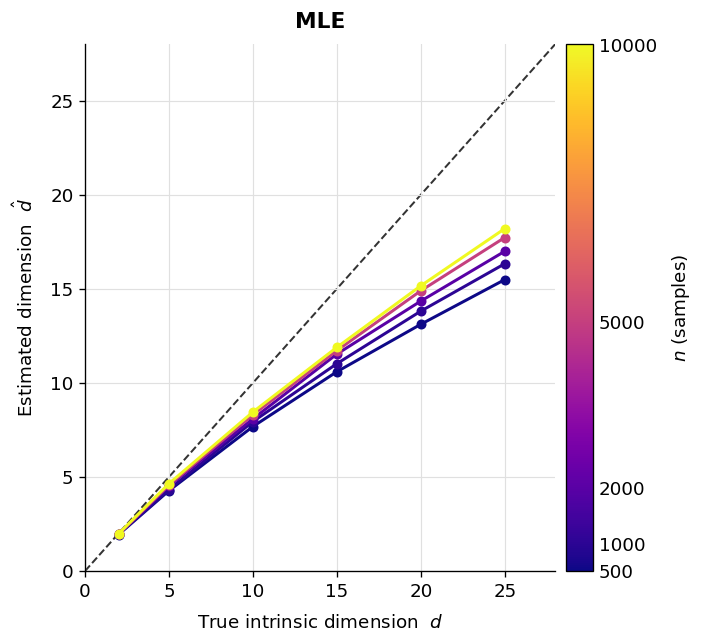

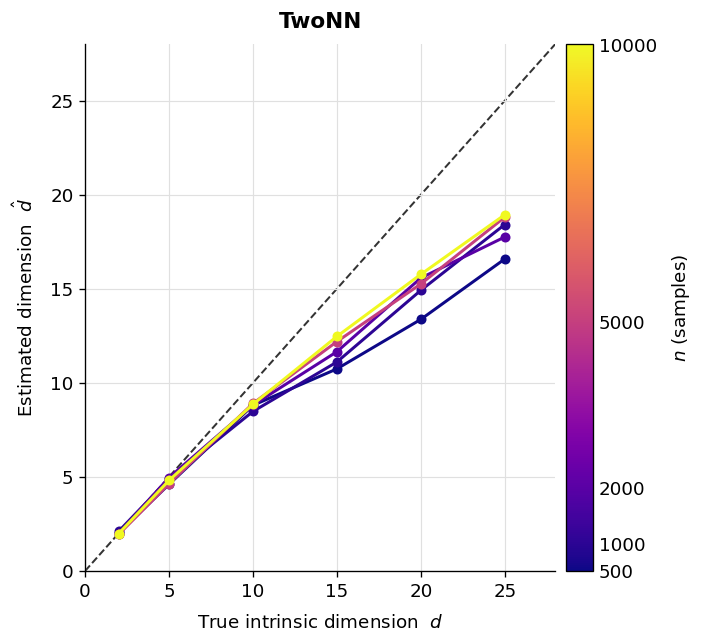

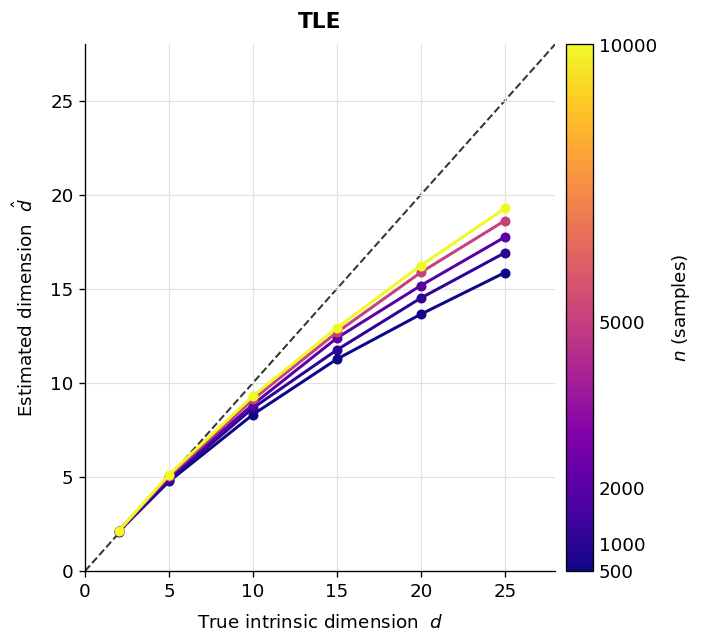

In [4]:
cmap = plt.cm.plasma
norm = Normalize(vmin=min(N_SAMPLES), vmax=max(N_SAMPLES))
diag = [0, max(D_TRUE_VALS) * 1.12]

for est_name in ESTIMATORS:
    fig, ax = plt.subplots(figsize=(6, 5.5))

    for n in N_SAMPLES:
        color = cmap(norm(n))
        ax.plot(D_TRUE_VALS, results[est_name][n],
                marker='o', markersize=5, linewidth=1.8,
                color=color, label=f"{n:,}")

    # Identity line
    ax.plot(diag, diag, color="#333333", linewidth=1.2,
            linestyle="--", zorder=0, label="ideal")

    ax.set_xlim(diag)
    ax.set_ylim(diag)
    ax.set_xlabel("True intrinsic dimension  $d$", labelpad=8)
    ax.set_ylabel("Estimated dimension  $\\hat{d}$", labelpad=8)
    ax.set_title(est_name, fontsize=13, fontweight="bold", pad=10)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

    # Colorbar for n_samples
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("$n$ (samples)", labelpad=8)
    cbar.set_ticks(N_SAMPLES)
    cbar.ax.yaxis.set_tick_params(length=0)

    fig.tight_layout()
    plt.savefig(f"results/{est_name}_dtrue_vs_dest.pdf", bbox_inches="tight")
    plt.show()

In [5]:
D_SWEEP      = [2, 5, 10, 15, 25, 30, 35, 40, 45, 50]
N_SWEEP      = [500, 1000, 2000, 5000, 10_000]

# results2[est_name][d] = [d_est for each n in N_SWEEP]
results2 = {name: {} for name in ESTIMATORS}

for est_name, est in ESTIMATORS.items():
    print(f"── {est_name} ──")
    for d in D_SWEEP:
        d_ests = []
        for n in N_SWEEP:
            X = generate_dataset(n_samples=n, intrinsic_dim=d, ambient_dim=AMBIENT_DIM, seed=42)
            d_ests.append(type(est)(**est.__dict__).fit(X).dimension_)
        results2[est_name][d] = d_ests
        print(f"  d={d:>3d} done")

── CorrInt ──


  d=  2 done


  d=  5 done


  d= 10 done


  d= 15 done


...

  d= 30 done


  d= 35 done


  d= 40 done


  d= 45 done


  d= 50 done


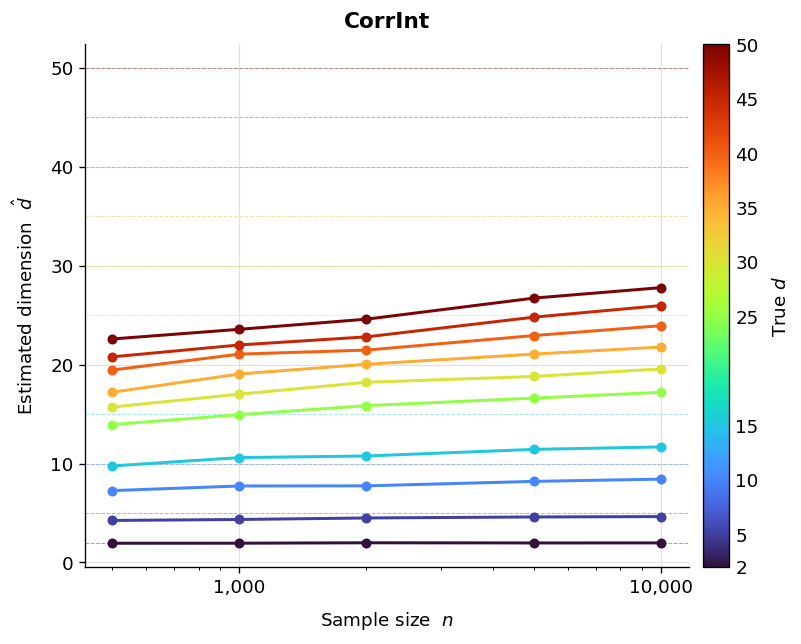

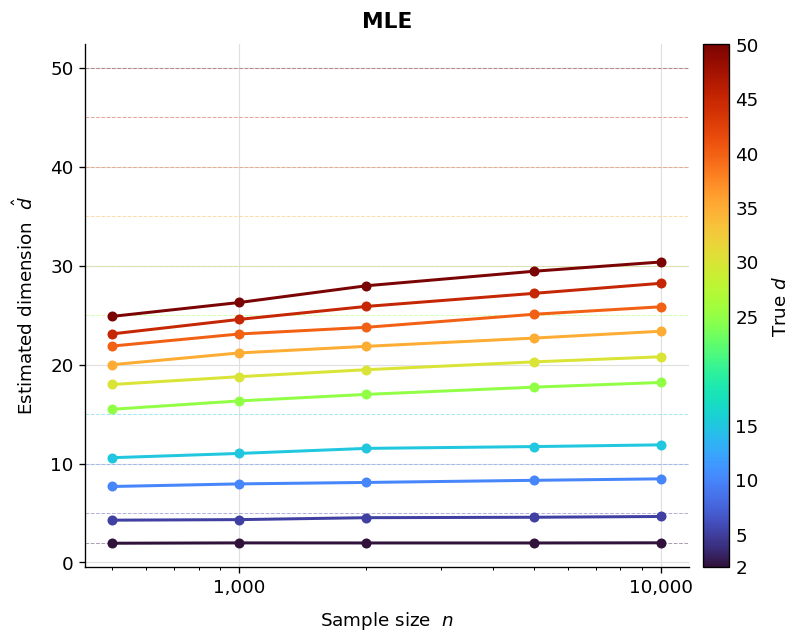

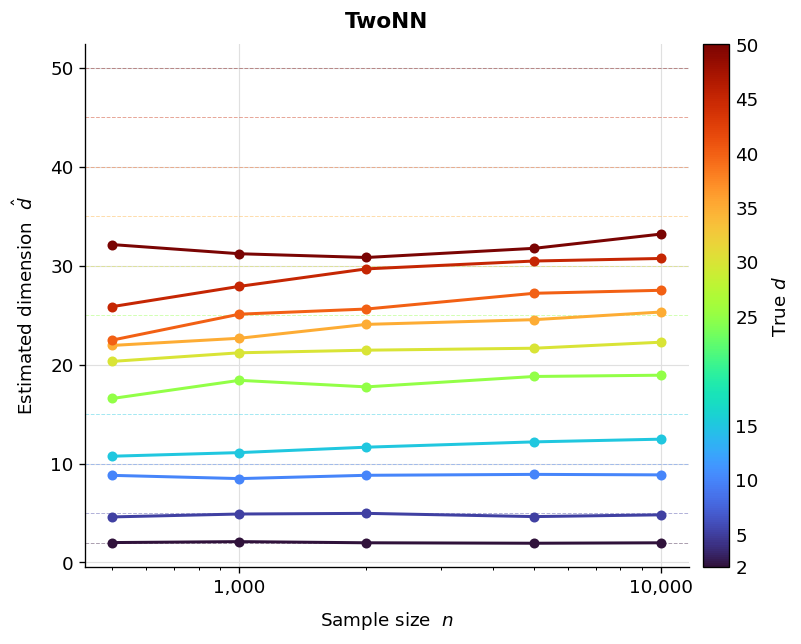

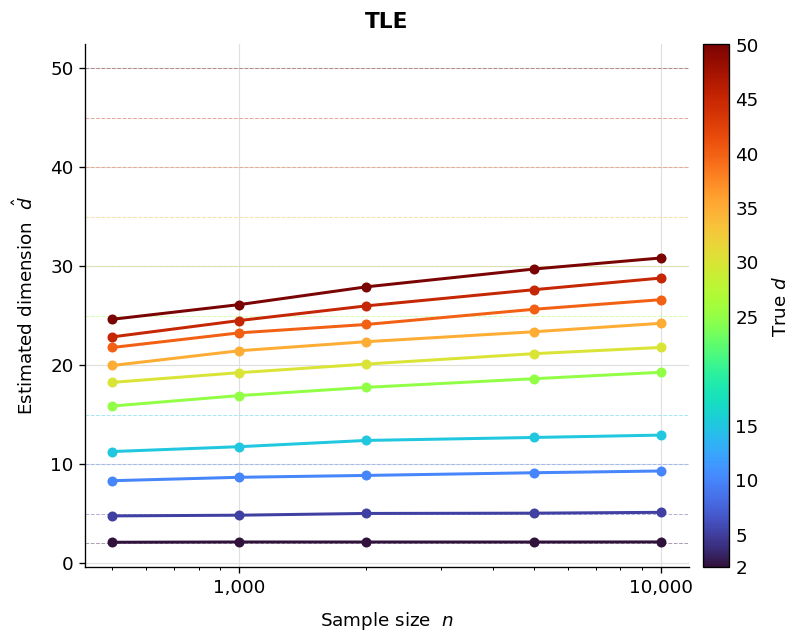

In [6]:
cmap2 = plt.cm.turbo
norm2 = Normalize(vmin=min(D_SWEEP), vmax=max(D_SWEEP))

for est_name in ESTIMATORS:
    fig, ax = plt.subplots(figsize=(7, 5.5))

    for d in D_SWEEP:
        color = cmap2(norm2(d))
        ax.plot(N_SWEEP, results2[est_name][d],
                marker='o', markersize=5, linewidth=1.8,
                color=color, label=str(d))
        ax.axhline(d, color=color, linewidth=0.6, linestyle="--", alpha=0.4)

    ax.set_xscale("log")
    ax.set_xlabel("Sample size  $n$", labelpad=8)
    ax.set_ylabel("Estimated dimension  $\\hat{d}$", labelpad=8)
    ax.set_title(est_name, fontsize=13, fontweight="bold", pad=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    sm2 = ScalarMappable(cmap=cmap2, norm=norm2)
    sm2.set_array([])
    cbar = fig.colorbar(sm2, ax=ax, pad=0.02)
    cbar.set_label("True $d$", labelpad=8)
    cbar.set_ticks(D_SWEEP)
    cbar.ax.yaxis.set_tick_params(length=0)

    fig.tight_layout()
    plt.savefig(f"results/{est_name}_dest_vs_n.pdf", bbox_inches="tight")
    plt.show()

In [7]:
D_LOW        = [1, 2, 3, 4, 5, 6]
D_EXTENDED   = [1, 2, 3, 4, 5, 6, 7, 8, 9]   # TwoNN and TLE only
ABS_THRESH   = 0.5
N_SEEDS      = 5
N_GRID       = np.unique(np.round(np.geomspace(50, 50_000, 80)).astype(int))

# min_n[est_name][d] = min n (or None)
min_n = {name: {} for name in ESTIMATORS}

for est_name, est in ESTIMATORS.items():
    d_vals = D_EXTENDED if est_name in ("TwoNN", "TLE") else D_LOW
    print(f"\n── {est_name} (d={d_vals}) ──")
    for d in d_vals:
        found = None
        for n in N_GRID:
            estimates = [
                type(est)(**est.__dict__).fit(
                    generate_dataset(n_samples=n, intrinsic_dim=d,
                                     ambient_dim=AMBIENT_DIM, seed=s)
                ).dimension_
                for s in range(N_SEEDS)
            ]
            if abs(np.mean(estimates) - d) <= ABS_THRESH:
                found = int(n)
                break
        min_n[est_name][d] = found
        print(f"  d={d}  min_n={'not reached' if found is None else found}")


── CorrInt (d=[1, 2, 3, 4, 5, 6]) ──
  d=1  min_n=50
  d=2  min_n=50
  d=3  min_n=84


  d=4  min_n=445


  d=5  min_n=2147


  d=6  min_n=19109

── MLE (d=[1, 2, 3, 4, 5, 6]) ──
  d=1  min_n=50
  d=2  min_n=50
  d=3  min_n=60


  d=4  min_n=287


...

  d=5  min_n=170


  d=6  min_n=486


  d=7  min_n=1387


  d=8  min_n=3629


  d=9  min_n=9494


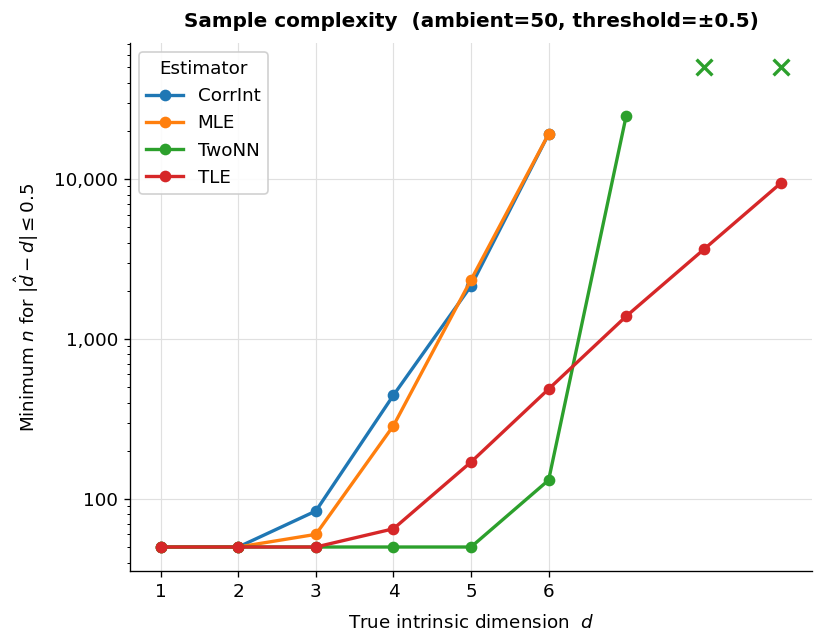

In [8]:
colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(7, 5.5))

for (est_name, d_map), color in zip(min_n.items(), colors):
    xs = [d for d, n in d_map.items() if n is not None]
    ys = [n for n in d_map.values() if n is not None]
    missing = [d for d, n in d_map.items() if n is None]

    ax.plot(xs, ys, marker='o', linewidth=2, markersize=6,
            color=color, label=est_name)

    if missing:
        ax.scatter(missing, [N_GRID[-1]] * len(missing),
                   marker='x', s=90, linewidths=2,
                   color=color, zorder=5)

ax.set_yscale("log")
ax.set_xticks(D_LOW)
ax.set_xlabel("True intrinsic dimension  $d$", labelpad=8)
ax.set_ylabel("Minimum $n$ for $|\\hat{d} - d| \\leq 0.5$", labelpad=8)
ax.set_title(f"Sample complexity  (ambient={AMBIENT_DIM}, threshold=±0.5)",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(title="Estimator", framealpha=0.9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
plt.savefig("results/min_samples_abs05.pdf", bbox_inches="tight")
plt.show()

## Noise sensitivity — estimated d vs η
Mirrors exp1_noise.py. Noise std = η × avg_pairwise_dist of the clean data.

In [9]:
ETA_VALUES   = [0.0, 0.001,0.005,0.01,0.02,0.05,0.1]
D_NOISE      = [2, 5, 10, 15, 20, 25, 30]
N_NOISE      = 2_000
N_RUNS_NOISE = 5
Z95          = 1.96

def add_noise(X: np.ndarray, eta: float, rng: np.random.Generator) -> np.ndarray:
    """Add i.i.d. Gaussian noise with std = eta * mean_pairwise_dist(X_subsample)."""
    if eta == 0.0:
        return X
    m = min(500, len(X))
    sub = X[rng.choice(len(X), m, replace=False)]
    diff = sub[:, None, :] - sub[None, :, :]
    avg_dist = float(np.sqrt((diff ** 2).sum(axis=-1))[np.triu_indices(m, k=1)].mean())
    return X + rng.normal(0.0, eta * avg_dist, size=X.shape)

# noise_results[est_name][d] -> ndarray (n_eta, N_RUNS_NOISE)
noise_results = {name: {d: np.full((len(ETA_VALUES), N_RUNS_NOISE), np.nan)
                         for d in D_NOISE}
                 for name in ESTIMATORS}

for est_name, est in ESTIMATORS.items():
    print(f"── {est_name} ──")
    for d in D_NOISE:
        X_clean = generate_dataset(n_samples=N_NOISE, intrinsic_dim=d,
                                   ambient_dim=AMBIENT_DIM, seed=42)
        for eta_idx, eta in enumerate(ETA_VALUES):
            for run in range(N_RUNS_NOISE):
                rng = np.random.default_rng(run * 1000 + eta_idx)
                X = add_noise(X_clean, eta, rng)
                try:
                    noise_results[est_name][d][eta_idx, run] = \
                        type(est)(**est.__dict__).fit(X).dimension_
                except Exception:
                    pass
        print(f"  d={d} done")

── CorrInt ──


  d=2 done


  d=5 done


  d=10 done


  d=15 done


...

  d=10 done


  d=15 done


  d=20 done


  d=25 done


  d=30 done


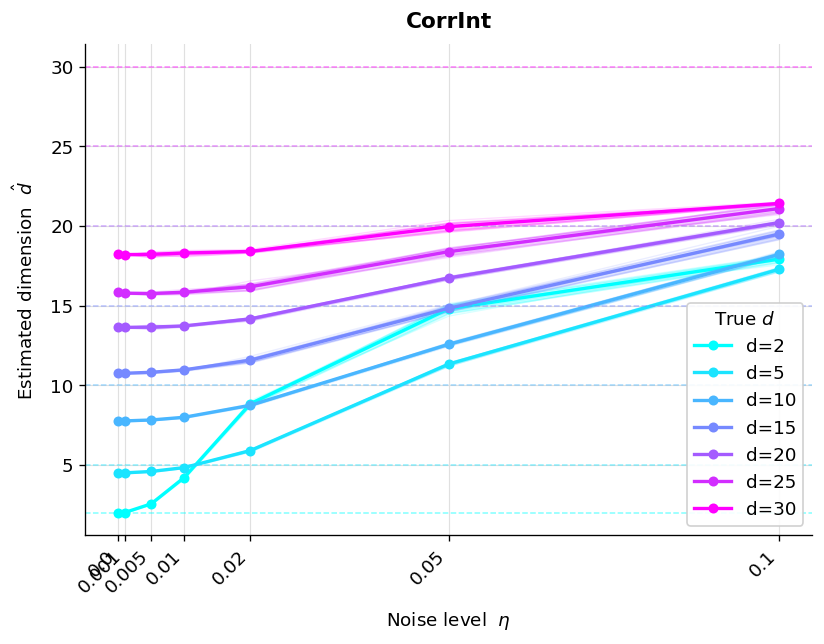

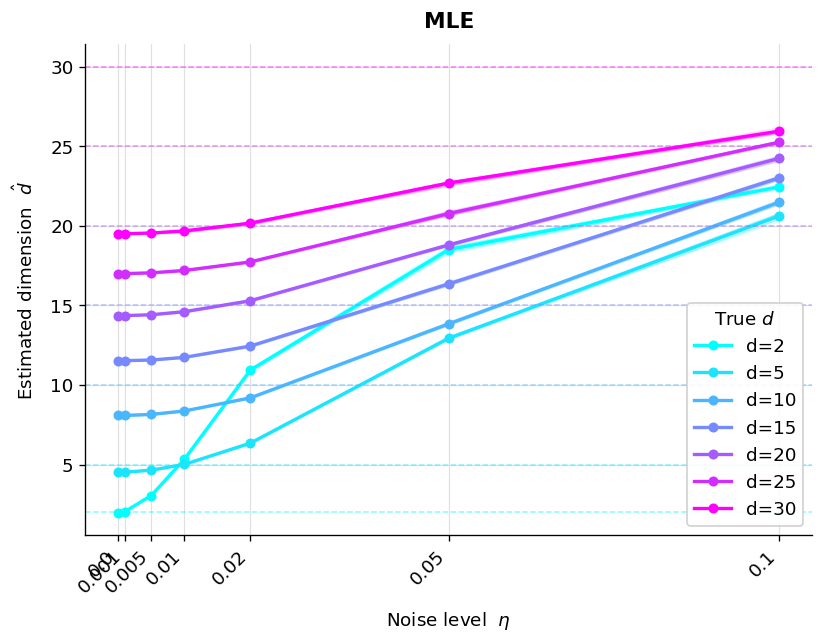

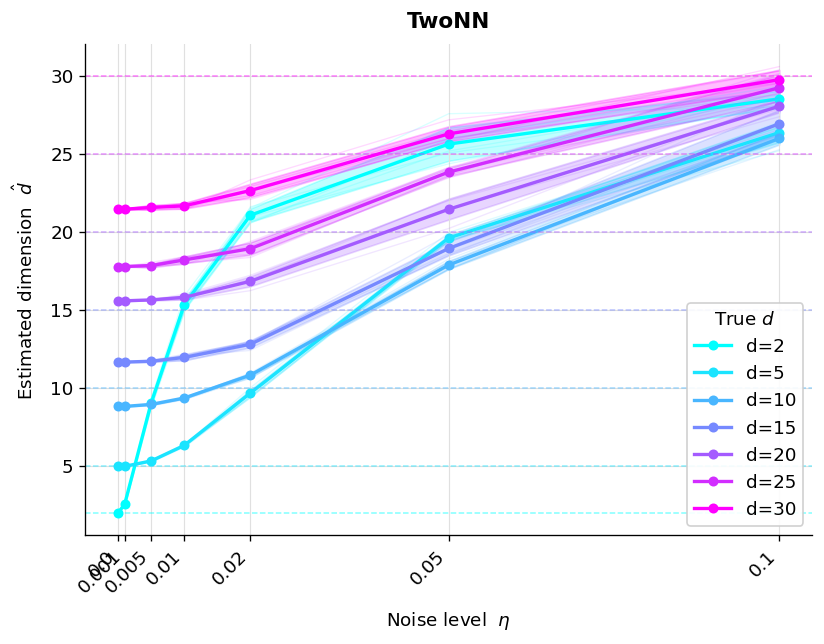

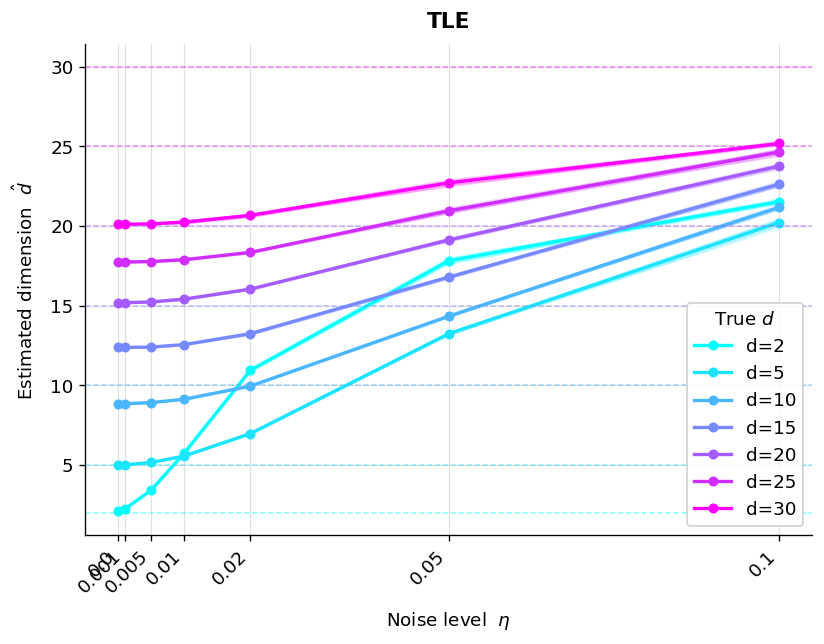

In [10]:
cmap_noise = plt.cm.cool
norm_noise = Normalize(vmin=min(D_NOISE), vmax=max(D_NOISE))
eta_arr = np.array(ETA_VALUES)

for est_name in ESTIMATORS:
    fig, ax = plt.subplots(figsize=(7, 5.5))

    for d in D_NOISE:
        data = noise_results[est_name][d]           # (n_eta, N_RUNS_NOISE)
        n_valid = np.sum(~np.isnan(data), axis=1).clip(1)
        mean = np.nanmean(data, axis=1)
        ci   = Z95 * np.nanstd(data, axis=1, ddof=1) / np.sqrt(n_valid)
        color = cmap_noise(norm_noise(d))

        # individual runs (faint)
        for run in range(N_RUNS_NOISE):
            ax.plot(eta_arr, data[:, run], color=color, alpha=0.15, linewidth=0.8)

        # CI band + mean line
        ax.fill_between(eta_arr, mean - ci, mean + ci, color=color, alpha=0.25)
        ax.plot(eta_arr, mean, color=color, linewidth=2,
                marker='o', markersize=5, label=f"d={d}")

        # true d reference
        ax.axhline(d, color=color, linestyle='--', linewidth=0.9, alpha=0.5)

    ax.set_xlabel("Noise level  $\\eta$", labelpad=8)
    ax.set_ylabel("Estimated dimension  $\\hat{d}$", labelpad=8)
    ax.set_title(est_name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xticks(ETA_VALUES)
    ax.set_xticklabels([str(e) for e in ETA_VALUES], rotation=45, ha='right')
    ax.legend(title="True $d$", framealpha=0.9)

    fig.tight_layout()
    plt.savefig(f"results/{est_name}_noise.pdf", bbox_inches="tight")
    plt.show()

## Johnson–Lindenstrauss distortion vs projection dimension m
For a random Gaussian JL projection P: R^D → R^m (scaled by 1/√m), the distortion for a pair (x,y) is |‖Px−Py‖/‖x−y‖ − 1|. We track the **maximum distortion** over all pairs as m grows.

In [11]:
from sklearn.metrics import pairwise_distances

def jl_distortion(X, m_values, n_pairs=5000, n_projections=10, seed=42):
    """
    For each m, run n_projections independent JL maps and return the
    best and mean *average* pairwise distortion across projections.
    m can exceed ambient dim D (super-ambient projection).

    Average distortion = mean over pairs of |‖Px-Py‖/‖x-y‖ - 1|.
    """
    rng = np.random.default_rng(seed)
    n, D = X.shape
    idx_a = rng.integers(0, n, size=n_pairs)
    idx_b = rng.integers(0, n, size=n_pairs)
    same  = idx_a == idx_b
    idx_b[same] = (idx_b[same] + 1) % n
    orig_dists = np.linalg.norm(X[idx_a] - X[idx_b], axis=1)
    valid = orig_dists > 0
    a_v, b_v, d_v = idx_a[valid], idx_b[valid], orig_dists[valid]

    best_dist = np.zeros(len(m_values))
    mean_dist = np.zeros(len(m_values))
    for i, m in enumerate(m_values):
        proj_avg = np.zeros(n_projections)
        for k in range(n_projections):
            P  = rng.standard_normal((D, m)) / np.sqrt(m)
            Xp = X @ P
            proj_dists  = np.linalg.norm(Xp[a_v] - Xp[b_v], axis=1)
            proj_avg[k] = np.abs(proj_dists / d_v - 1.0).mean()  # avg over pairs
        best_dist[i] = proj_avg.min()
        mean_dist[i] = proj_avg.mean()
    return best_dist, mean_dist


# ── Settings ──────────────────────────────────────────────────────────────────
JL_AMBIENT    = 50
JL_D_TRUE     = 5
JL_N          = 1_000
M_VALUES      = list(range(1, 4 * JL_AMBIENT + 1, 2))
N_PAIRS       = 5_000
N_PROJECTIONS = 20

X_jl = generate_dataset(n_samples=JL_N, intrinsic_dim=JL_D_TRUE,
                         ambient_dim=JL_AMBIENT, seed=42)

best_dist, mean_dist = jl_distortion(
    X_jl, M_VALUES, n_pairs=N_PAIRS, n_projections=N_PROJECTIONS, seed=0
)
print(f'Dataset: d={JL_D_TRUE}, ambient={JL_AMBIENT}, n={JL_N}, projections={N_PROJECTIONS}')
print(f'Best avg distortion at m=1:               {best_dist[0]:.4f}')
idx_ambient = min(range(len(M_VALUES)), key=lambda i: abs(M_VALUES[i] - JL_AMBIENT))
print(f'Best avg distortion at m~{JL_AMBIENT} (ambient): {best_dist[idx_ambient]:.4f}')
print(f'Best avg distortion at m={4*JL_AMBIENT} (4x ambient): {best_dist[-1]:.4f}')


Dataset: d=5, ambient=50, n=1000, projections=20
Best avg distortion at m=1:               0.4594
Best avg distortion at m~50 (ambient): 0.0496
Best avg distortion at m=200 (4x ambient): 0.0276


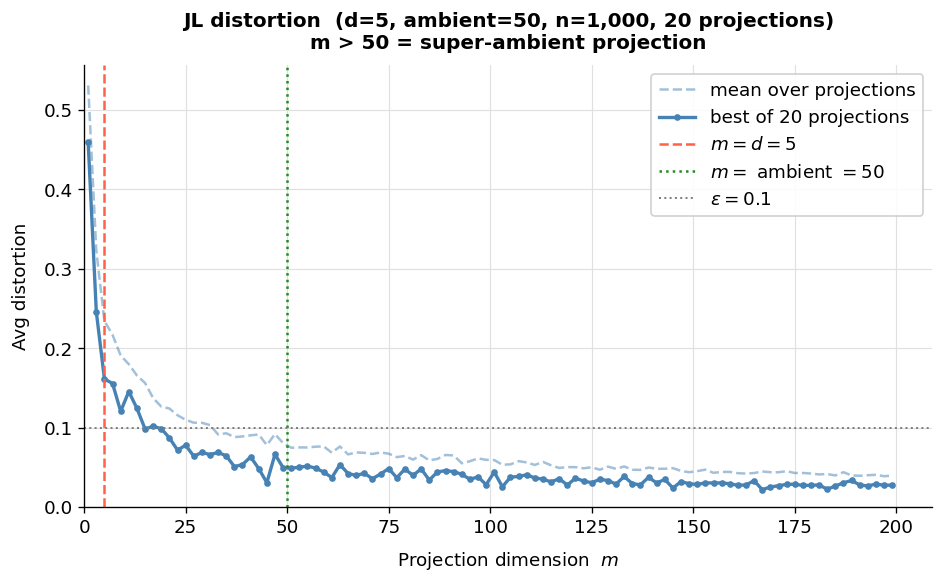

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(M_VALUES, mean_dist, linewidth=1.5, color='steelblue',
        alpha=0.5, linestyle='--', label='mean over projections')
ax.plot(M_VALUES, best_dist, linewidth=2, color='steelblue',
        marker='o', markersize=3, label=f'best of {N_PROJECTIONS} projections')

ax.axvline(JL_D_TRUE, color='tomato', linestyle='--', linewidth=1.5,
           label=f'$m = d = {JL_D_TRUE}$')
ax.axvline(JL_AMBIENT, color='forestgreen', linestyle=':', linewidth=1.5,
           label=f'$m = $ ambient $= {JL_AMBIENT}$')
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='$\\varepsilon = 0.1$')

ax.set_xlabel('Projection dimension  $m$', labelpad=8)
ax.set_ylabel('Avg distortion', labelpad=8)
ax.set_title(
    f'JL distortion  (d={JL_D_TRUE}, ambient={JL_AMBIENT}, '
    f'n={JL_N:,}, {N_PROJECTIONS} projections)\n'
    f'm > {JL_AMBIENT} = super-ambient projection',
    fontsize=12, fontweight='bold', pad=10)
ax.legend(framealpha=0.9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.savefig('results/jl_distortion.pdf', bbox_inches='tight')
plt.show()


In [13]:
EST_JL      = MLE()
N_PROJ_JL   = 20

rng_jl = np.random.default_rng(0)
n, D = X_jl.shape   # D = JL_AMBIENT = 50

# Fixed pairs for consistent distortion measurement
idx_a = rng_jl.integers(0, n, size=N_PAIRS)
idx_b = rng_jl.integers(0, n, size=N_PAIRS)
same  = idx_a == idx_b
idx_b[same] = (idx_b[same] + 1) % n
orig_dists = np.linalg.norm(X_jl[idx_a] - X_jl[idx_b], axis=1)
valid = orig_dists > 0
a_v, b_v, d_v = idx_a[valid], idx_b[valid], orig_dists[valid]

records = []   # (m, avg_distortion, d_est)

for m in M_VALUES:
    for _ in range(N_PROJ_JL):
        P   = rng_jl.standard_normal((D, m)) / np.sqrt(m)
        Xp  = X_jl @ P

        proj_dists  = np.linalg.norm(Xp[a_v] - Xp[b_v], axis=1)
        distortion  = np.abs(proj_dists / d_v - 1.0).mean()  # avg over pairs

        try:
            d_est = type(EST_JL)(**EST_JL.__dict__).fit(Xp).dimension_
        except Exception:
            d_est = np.nan

        records.append((m, distortion, d_est))

rec = np.array(records)
print(f'Collected {len(rec)} (m, avg_distortion, d_est) points  '
      f'[ambient={JL_AMBIENT}, d_true={JL_D_TRUE}, estimator={type(EST_JL).__name__}]')


Collected 2000 (m, avg_distortion, d_est) points  [ambient=50, d_true=5, estimator=MLE]


d_est on original data: 4.3283  (true d=5)


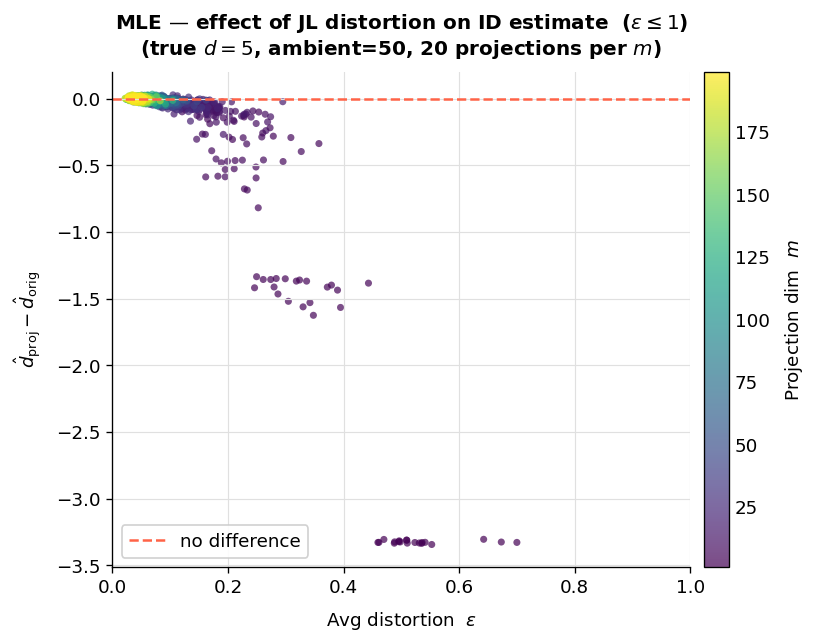

Showing 2000 / 2000 points  (distortion ≤ 1)


In [14]:
MAX_DISTORTION = 1

# d_est on the original (unprojected) data
d_est_original = type(EST_JL)(**EST_JL.__dict__).fit(X_jl).dimension_
print(f"d_est on original data: {d_est_original:.4f}  (true d={JL_D_TRUE})")

mask = rec[:, 1] <= MAX_DISTORTION
rec_plot = rec[mask]
delta = rec_plot[:, 2] - d_est_original   # d_est(proj) - d_est(original)

fig, ax = plt.subplots(figsize=(7, 5.5))

cmap_m = plt.cm.viridis
norm_m = Normalize(vmin=min(M_VALUES), vmax=max(M_VALUES))

sc = ax.scatter(rec_plot[:, 1], delta,
                c=rec_plot[:, 0], cmap=cmap_m, norm=norm_m,
                s=18, alpha=0.7, linewidths=0)

ax.axhline(0, color='tomato', linestyle='--', linewidth=1.5, label="no difference")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Projection dim  $m$", labelpad=8)
cbar.ax.yaxis.set_tick_params(length=0)

ax.set_xlim(0, MAX_DISTORTION)
ax.set_xlabel("Avg distortion  $\\varepsilon$", labelpad=8)
ax.set_ylabel("$\\hat{d}_{\\mathrm{proj}} - \\hat{d}_{\\mathrm{orig}}$", labelpad=8)
ax.set_title(
    f"{type(EST_JL).__name__} — effect of JL distortion on ID estimate  ($\\varepsilon \\leq {MAX_DISTORTION}$)\n"
    f"(true $d={JL_D_TRUE}$, ambient={JL_AMBIENT}, {N_PROJ_JL} projections per $m$)",
    fontsize=12, fontweight="bold", pad=10)
ax.legend(framealpha=0.9)

fig.tight_layout()
plt.savefig(f"results/jl_delta_vs_distortion_{type(EST_JL).__name__}.pdf", bbox_inches="tight")
plt.show()

print(f"Showing {mask.sum()} / {len(rec)} points  (distortion ≤ {MAX_DISTORTION})")

d=2 done


d=5 done


d=10 done


d=20 done


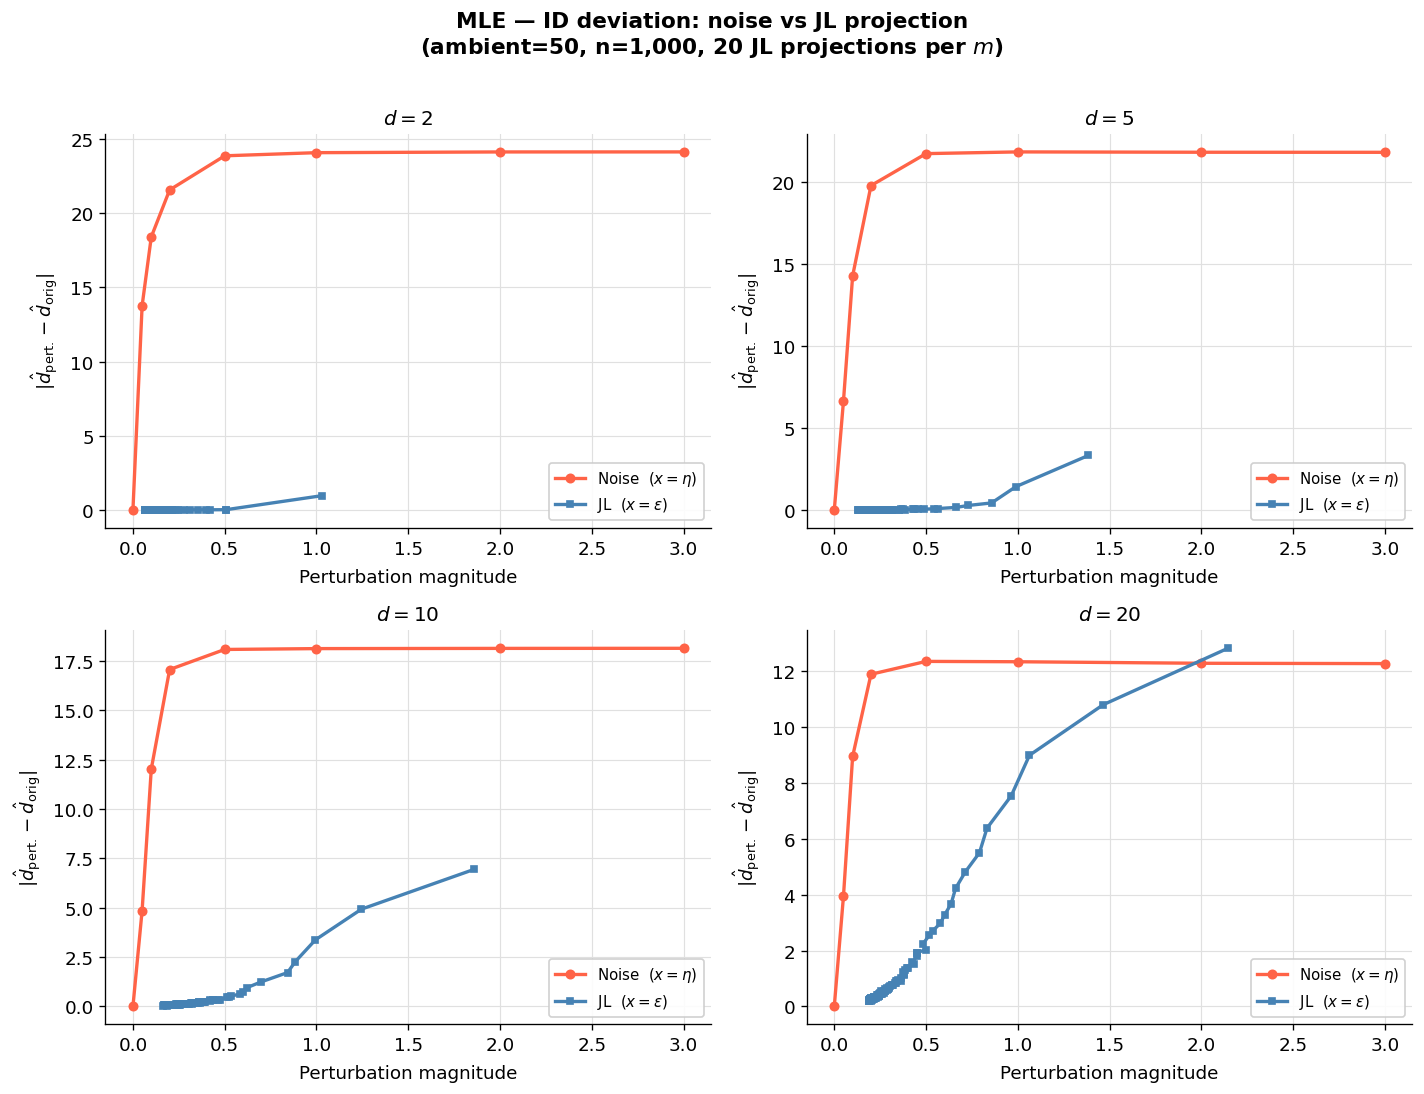

In [15]:
D_COMPARE   = [2, 5, 10, 20]
ETA_COMPARE = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0]
N_RUNS_CMP  = 10

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
axes = axes.flatten()

for ax, d in zip(axes, D_COMPARE):
    X_d = generate_dataset(n_samples=JL_N, intrinsic_dim=d,
                           ambient_dim=JL_AMBIENT, seed=42)

    # baseline: d_est on clean original data
    d_est_orig = type(EST_JL)(**EST_JL.__dict__).fit(X_d).dimension_

    # noise curve
    noise_deltas = []
    for eta in ETA_COMPARE:
        diffs = [
            abs(type(EST_JL)(**EST_JL.__dict__).fit(
                add_noise(X_d, eta, np.random.default_rng(s))
            ).dimension_ - d_est_orig)
            for s in range(N_RUNS_CMP)
        ]
        noise_deltas.append(np.mean(diffs))

    # JL curve
    rng_d = np.random.default_rng(0)
    n_, D_ = X_d.shape
    idx_a = rng_d.integers(0, n_, size=N_PAIRS)
    idx_b = rng_d.integers(0, n_, size=N_PAIRS)
    same  = idx_a == idx_b
    idx_b[same] = (idx_b[same] + 1) % n_
    orig_d = np.linalg.norm(X_d[idx_a] - X_d[idx_b], axis=1)
    v = orig_d > 0
    av, bv, dv = idx_a[v], idx_b[v], orig_d[v]

    jl_x, jl_y = [], []
    for m in M_VALUES:
        dists_m, deltas_m = [], []
        for _ in range(N_PROJ_JL):
            P  = rng_d.standard_normal((D_, m)) / np.sqrt(m)
            Xp = X_d @ P
            pd = np.linalg.norm(Xp[av] - Xp[bv], axis=1)
            dists_m.append(np.abs(pd / dv - 1.0).max())
            try:
                deltas_m.append(abs(
                    type(EST_JL)(**EST_JL.__dict__).fit(Xp).dimension_ - d_est_orig
                ))
            except Exception:
                deltas_m.append(np.nan)
        jl_x.append(np.mean(dists_m))
        jl_y.append(np.nanmean(deltas_m))

    ax.plot(ETA_COMPARE, noise_deltas,
            marker='o', markersize=5, linewidth=2, color='tomato',
            label='Noise  ($x = \\eta$)')
    ax.plot(jl_x, jl_y,
            marker='s', markersize=4, linewidth=2, color='steelblue',
            label='JL  ($x = \\varepsilon$)')
    ax.set_title(f'$d = {d}$', fontsize=12, fontweight='bold')
    ax.set_xlabel('Perturbation magnitude', labelpad=6)
    ax.set_ylabel('$|\\hat{d}_{\\mathrm{pert.}} - \\hat{d}_{\\mathrm{orig}}|$', labelpad=6)
    ax.legend(framealpha=0.9, fontsize=9)
    print(f'd={d} done')

fig.suptitle(
    f"{type(EST_JL).__name__} — ID deviation: noise vs JL projection\n"
    f"(ambient={JL_AMBIENT}, n={JL_N:,}, {N_PROJ_JL} JL projections per $m$)",
    fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig(f'results/noise_vs_jl_deviation_{type(EST_JL).__name__}_multid.pdf',
            bbox_inches='tight')
plt.show()


## Boundary bias
Points near the boundary of `[-1,1]^d` have fewer neighbours on one side, biasing local ID estimates downward. 
We compute a **per-point local ID** for each estimator by fitting on each point's k-NN neighbourhood, 
then plot it against the point's distance to the nearest face.

In [16]:
from sklearn.neighbors import NearestNeighbors
from scipy import stats

BDRY_D    = 10
BDRY_N    = 3_000
BDRY_K    = 80
N_REPS    = 5     # independent dataset repetitions

# Pool (boundary_dist, knn_idx, X) across all repetitions
all_X         = []
all_bdry_dist = []
all_knn_idx   = []

for rep in range(N_REPS):
    rng_r = np.random.default_rng(rep)
    X_r   = rng_r.uniform(-1, 1, size=(BDRY_N, BDRY_D))
    bd_r  = np.min(np.minimum(X_r + 1, 1 - X_r), axis=1)
    nn_r  = NearestNeighbors(n_neighbors=BDRY_K + 1).fit(X_r)
    _, idx_r = nn_r.kneighbors(X_r)
    all_X.append(X_r)
    all_bdry_dist.append(bd_r)
    all_knn_idx.append(idx_r[:, 1:])

print(f'Dataset: [-1,1]^{BDRY_D},  n={BDRY_N} x {N_REPS} reps = {BDRY_N*N_REPS:,} total points')


Dataset: [-1,1]^10,  n=3000 x 5 reps = 15,000 total points


In [17]:
BDRY_ESTIMATORS = {
    'CorrInt': CorrInt(),
    'MLE':     MLE(),
    'TwoNN':   TwoNN(),
    'TLE':     TLE(),
}

# local_dim[est_name] = (N_REPS * BDRY_N,) pooled per-point estimates
local_dim  = {}
pooled_dist = np.concatenate(all_bdry_dist)  # (N_REPS*BDRY_N,)

for est_name, est in BDRY_ESTIMATORS.items():
    print(f'-- {est_name} --')
    pw_all = []

    for rep in range(N_REPS):
        X_r   = all_X[rep]
        idx_r = all_knn_idx[rep]

        if est_name in ('MLE', 'TLE'):
            fitted = type(est)(**est.__dict__).fit(X_r)
            pw_all.append(fitted.dimension_pw_.copy())
        else:
            pw = np.full(BDRY_N, np.nan)
            for i in range(BDRY_N):
                try:
                    pw[i] = type(est)(**est.__dict__).fit(X_r[idx_r[i]]).dimension_
                except Exception:
                    pass
            pw_all.append(pw)
        print(f'  rep {rep+1}/{N_REPS} done')

    pooled_pw = np.concatenate(pw_all)
    local_dim[est_name] = pooled_pw

    # Linear regression: local d̂ ~ boundary distance
    valid = np.isfinite(pooled_pw)
    slope, intercept, r, pval, se = stats.linregress(
        pooled_dist[valid], pooled_pw[valid]
    )
    print(f'  slope={slope:.4f}  intercept={intercept:.4f}  '
          f'r={r:.4f}  p={pval:.2e}  (n={valid.sum():,})')


-- CorrInt --


  rep 1/5 done


  rep 2/5 done


  rep 3/5 done


  rep 4/5 done


...

  rep 1/5 done


  rep 2/5 done


  rep 3/5 done


  rep 4/5 done


  rep 5/5 done
  slope=1.5220  intercept=8.8697  r=0.0633  p=8.73e-15  (n=15,000)


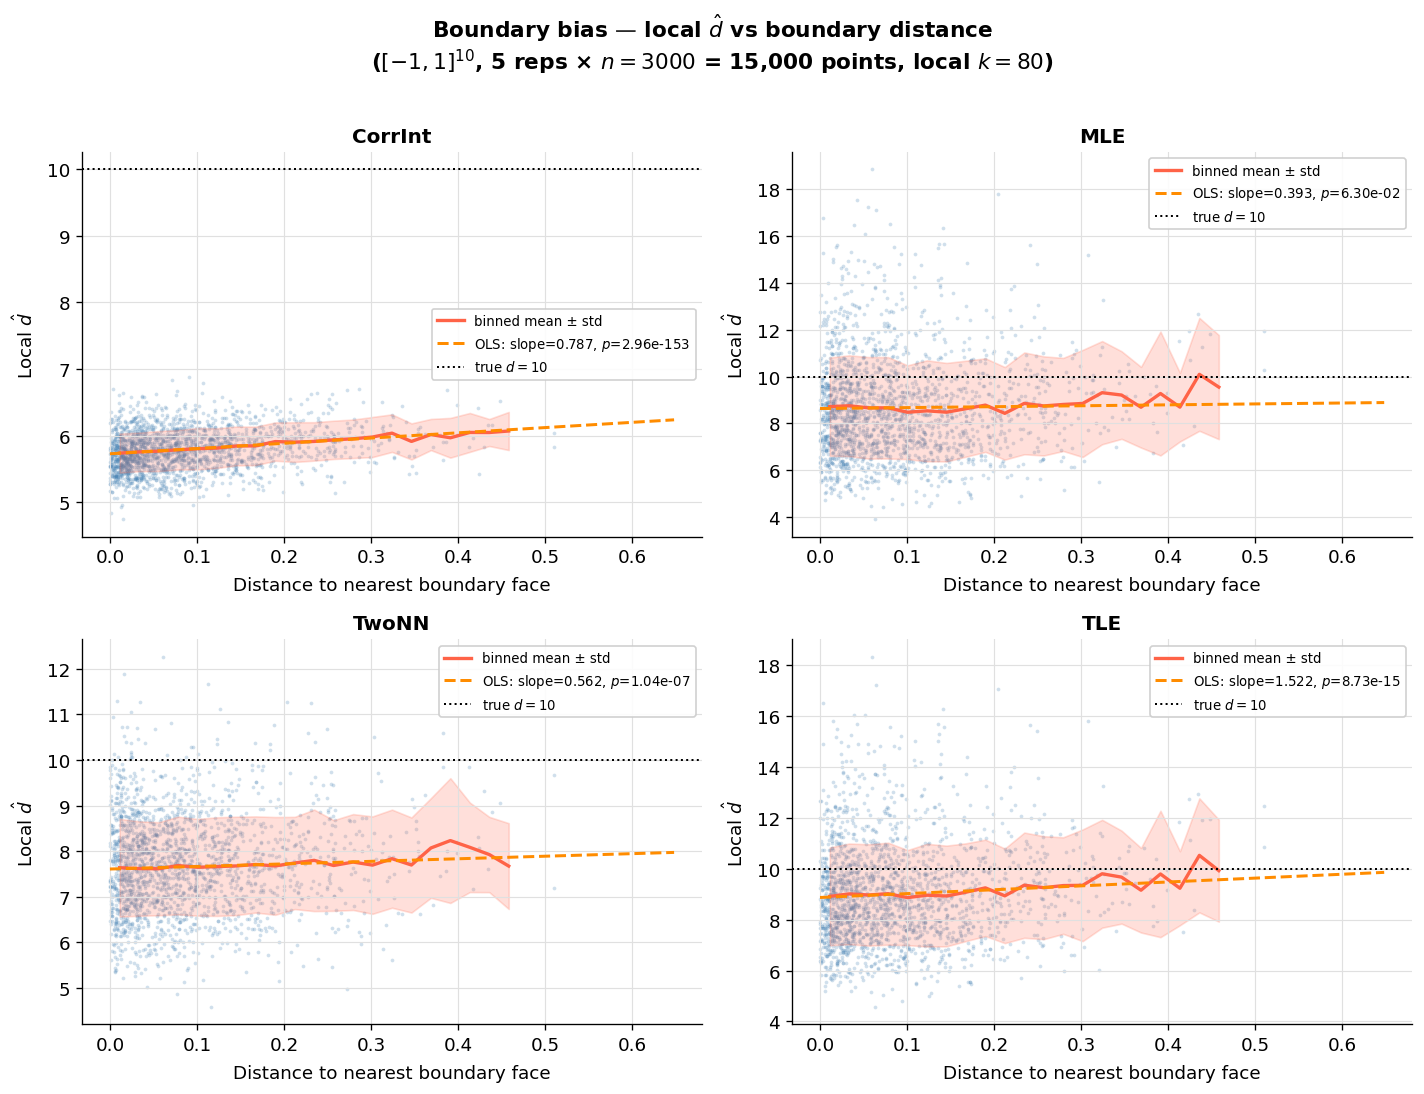

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
axes = axes.flatten()

for ax, (est_name, pw) in zip(axes, local_dim.items()):
    valid = np.isfinite(pw)
    x = pooled_dist[valid]
    y = pw[valid]

    # Linear regression + p-value
    slope, intercept, r, pval, se = stats.linregress(x, y)

    # Scatter (subsampled)
    sub = np.random.default_rng(0).choice(len(x), min(2000, len(x)), replace=False)
    ax.scatter(x[sub], y[sub], s=5, alpha=0.25, color='steelblue', linewidths=0)

    # Binned mean ± std
    bins = np.linspace(0, x.max(), 30)
    centers, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x >= lo) & (x < hi)
        if mask.sum() > 10:
            centers.append((lo + hi) / 2)
            means.append(np.mean(y[mask]))
            stds.append(np.std(y[mask]))
    centers, means, stds = map(np.array, (centers, means, stds))
    ax.fill_between(centers, means - stds, means + stds, color='tomato', alpha=0.2)
    ax.plot(centers, means, color='tomato', linewidth=2, label='binned mean ± std')

    # OLS regression line
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, intercept + slope * x_line,
            color='darkorange', linewidth=1.8, linestyle='--',
            label=f'OLS: slope={slope:.3f}, $p$={pval:.2e}')

    ax.axhline(BDRY_D, color='black', linestyle=':', linewidth=1.2,
               label=f'true $d={BDRY_D}$')

    ax.set_title(est_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance to nearest boundary face', labelpad=6)
    ax.set_ylabel('Local $\\hat{d}$', labelpad=6)
    ax.legend(fontsize=8, framealpha=0.9)

fig.suptitle(
    f'Boundary bias — local $\\hat{{d}}$ vs boundary distance\n'
    f'($[-1,1]^{{{BDRY_D}}}$, {N_REPS} reps × $n={BDRY_N}$ = {N_REPS*BDRY_N:,} points, local $k={BDRY_K}$)',
    fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('results/boundary_bias.pdf', bbox_inches='tight')
plt.show()


In [19]:
# ── Trimming sweep ────────────────────────────────────────────────────────────
# For each delta, discard points with boundary_dist < delta, then:
#  (a) fit each estimator globally -> d̂_global
#  (b) linear regression of local d̂ vs boundary_dist -> p-value

DELTA_VALUES = np.linspace(0.0, 0.4, 20)   # trim thresholds

# trim_results[est_name]['d_hat']  -> (n_delta, N_REPS)  global estimates
# trim_results[est_name]['pval']   -> (n_delta, N_REPS)  regression p-values
trim_results = {
    name: {'d_hat': np.full((len(DELTA_VALUES), N_REPS), np.nan),
           'pval':  np.full((len(DELTA_VALUES), N_REPS), np.nan)}
    for name in BDRY_ESTIMATORS
}

for rep in range(N_REPS):
    X_r   = all_X[rep]
    bd_r  = all_bdry_dist[rep]
    idx_r = all_knn_idx[rep]
    pw_r  = {name: local_dim[name][rep*BDRY_N:(rep+1)*BDRY_N]
             for name in BDRY_ESTIMATORS}

    for di, delta in enumerate(DELTA_VALUES):
        keep = bd_r >= delta
        X_trim = X_r[keep]
        if len(X_trim) < BDRY_K + 5:
            continue

        for est_name, est in BDRY_ESTIMATORS.items():
            # (a) global d̂ on trimmed set
            try:
                d_hat = type(est)(**est.__dict__).fit(X_trim).dimension_
                trim_results[est_name]['d_hat'][di, rep] = d_hat
            except Exception:
                pass

            # (b) p-value: regression of per-point local d̂ vs boundary dist
            #     using only the kept points (local d̂ already computed)
            pw_keep = pw_r[est_name][keep]
            bd_keep = bd_r[keep]
            valid   = np.isfinite(pw_keep)
            if valid.sum() > 10:
                _, _, _, pval, _ = stats.linregress(
                    bd_keep[valid], pw_keep[valid]
                )
                trim_results[est_name]['pval'][di, rep] = pval

    print(f'rep {rep+1}/{N_REPS} done')

print('Trimming sweep complete.')


rep 1/5 done


rep 2/5 done


rep 3/5 done


rep 4/5 done


rep 5/5 done
Trimming sweep complete.


/var/folders/n4/d_65zvmn6vq6hmtg9jbcrldr0000gn/T/ipykernel_65978/688153140.py:14: RuntimeWarning: Mean of empty slice
  d_mean = np.nanmean(d_hat, axis=1)
/opt/homebrew/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/n4/d_65zvmn6vq6hmtg9jbcrldr0000gn/T/ipykernel_65978/688153140.py:16: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(pvals, axis=1)
/var/folders/n4/d_65zvmn6vq6hmtg9jbcrldr0000gn/T/ipykernel_65978/688153140.py:14: RuntimeWarning: Mean of empty slice
  d_mean = np.nanmean(d_hat, axis=1)
/opt/homebrew/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/n4/d_65zvmn6vq6hmtg9jbcrldr0000gn/T/ipykernel_65978/688153140.py:16: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(pvals, 

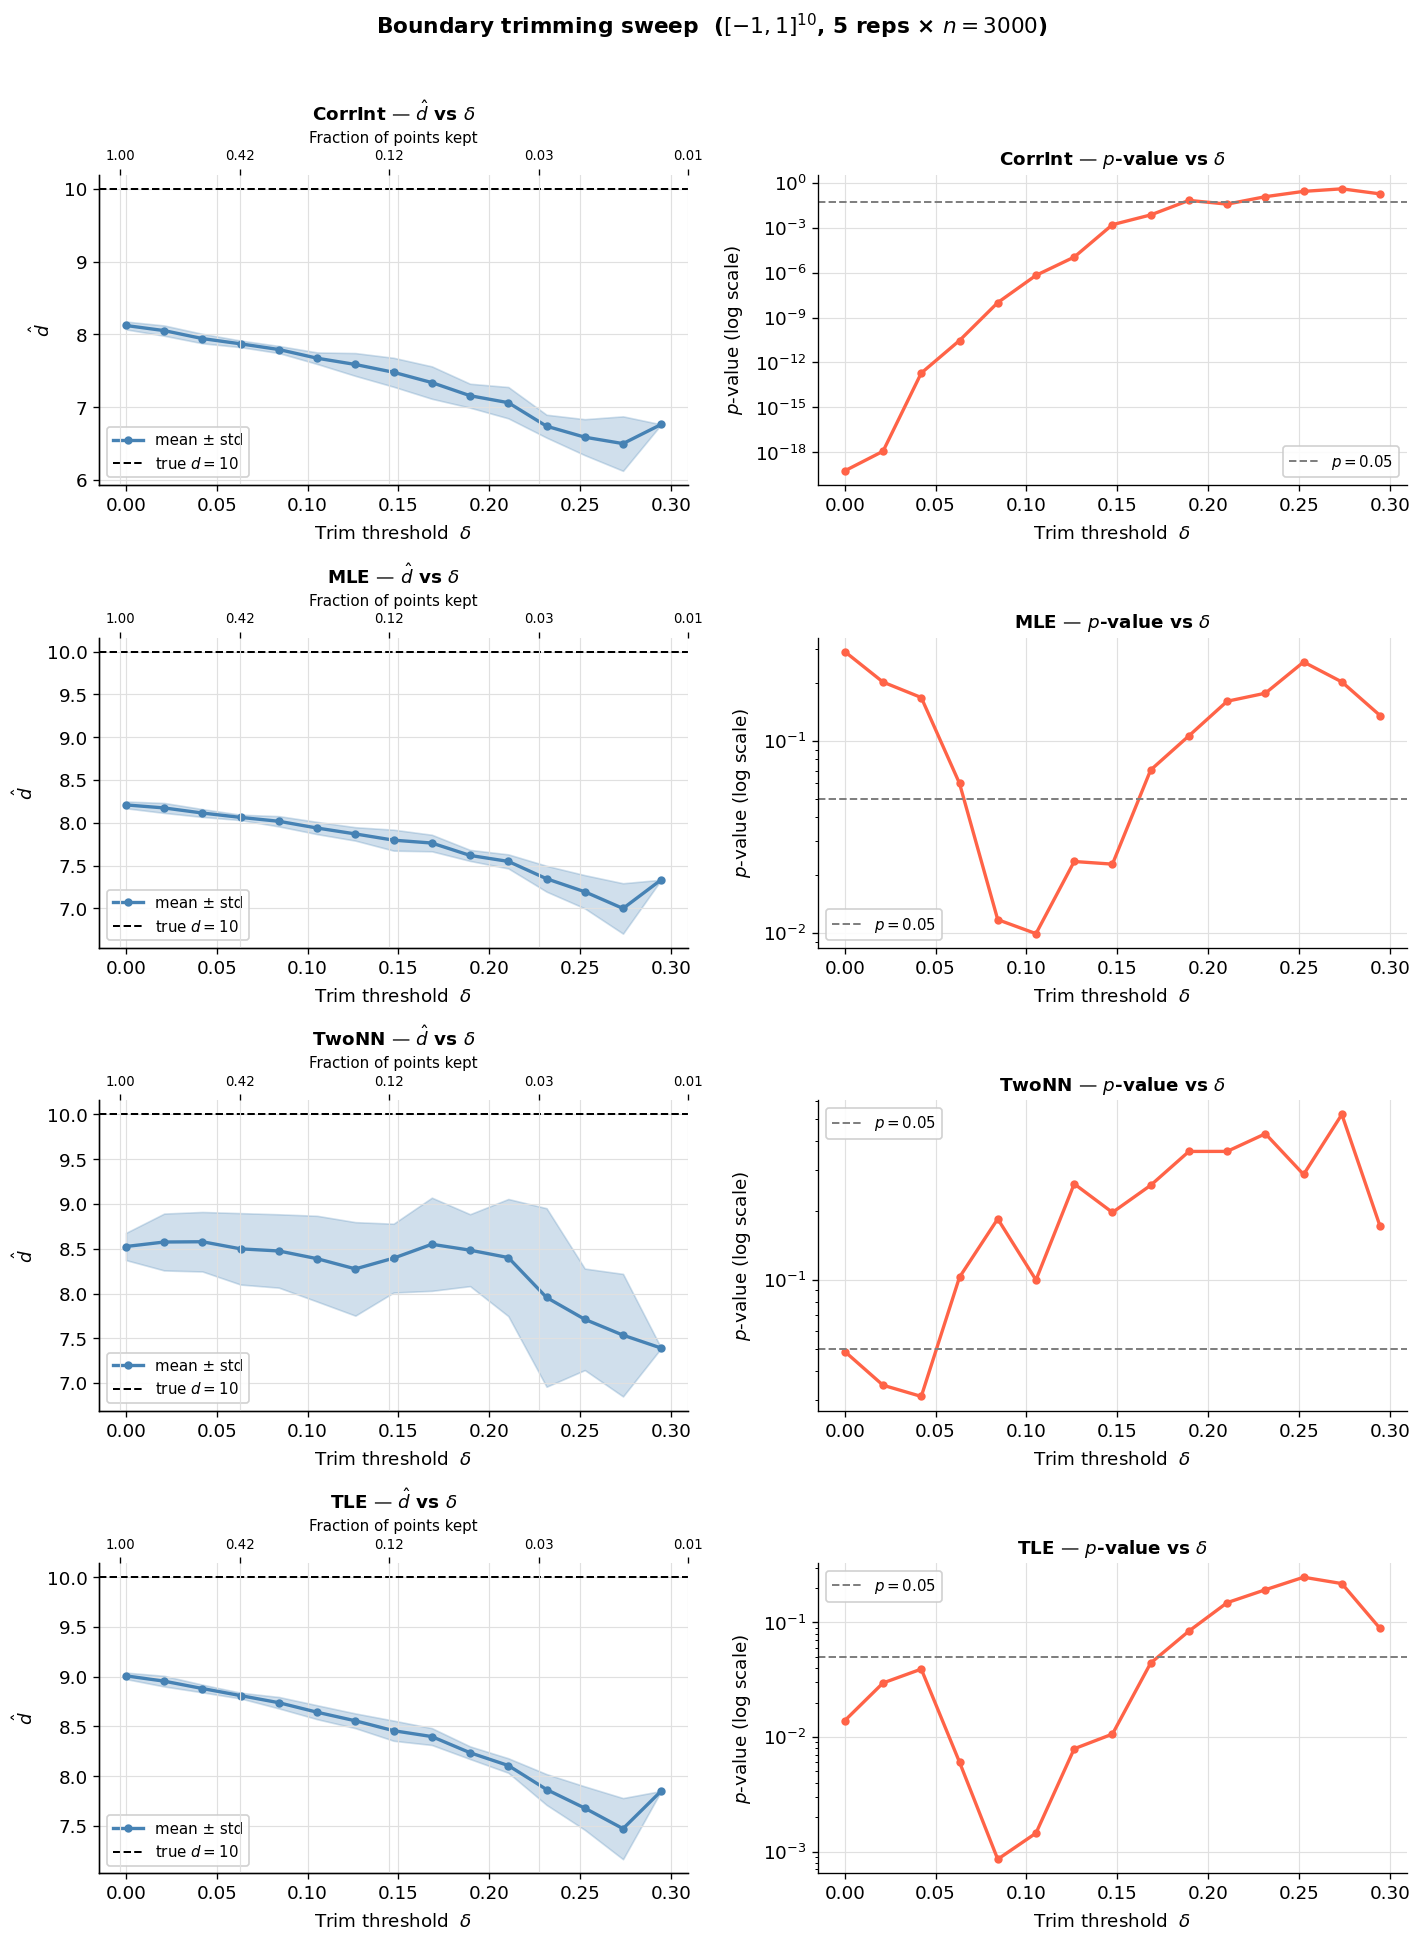

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
n_keep_frac = np.array([
    np.mean([np.mean(all_bdry_dist[r] >= d) for r in range(N_REPS)])
    for d in DELTA_VALUES
])

for row, est_name in enumerate(BDRY_ESTIMATORS):
    ax_d   = axes[row, 0]
    ax_p   = axes[row, 1]

    d_hat  = trim_results[est_name]['d_hat']   # (n_delta, N_REPS)
    pvals  = trim_results[est_name]['pval']

    d_mean = np.nanmean(d_hat, axis=1)
    d_std  = np.nanstd(d_hat,  axis=1)
    p_mean = np.nanmean(pvals, axis=1)

    # ── Left: d̂ vs delta ──────────────────────────────────────────────────
    ax_d.fill_between(DELTA_VALUES, d_mean - d_std, d_mean + d_std,
                      color='steelblue', alpha=0.25)
    ax_d.plot(DELTA_VALUES, d_mean, color='steelblue', linewidth=2,
              marker='o', markersize=4, label='mean ± std')
    ax_d.axhline(BDRY_D, color='black', linestyle='--', linewidth=1.2,
                 label=f'true $d={BDRY_D}$')

    # Secondary x-axis: fraction of points kept
    ax_d2 = ax_d.twiny()
    ax_d2.set_xlim(ax_d.get_xlim())
    tick_idx = np.linspace(0, len(DELTA_VALUES)-1, 5, dtype=int)
    ax_d2.set_xticks(DELTA_VALUES[tick_idx])
    ax_d2.set_xticklabels([f'{n_keep_frac[i]:.2f}' for i in tick_idx], fontsize=8)
    ax_d2.set_xlabel('Fraction of points kept', fontsize=9, labelpad=4)

    ax_d.set_xlabel('Trim threshold  $\\delta$', labelpad=6)
    ax_d.set_ylabel('$\\hat{d}$', labelpad=6)
    ax_d.set_title(f'{est_name} — $\\hat{{d}}$ vs $\\delta$',
                   fontsize=11, fontweight='bold')
    ax_d.legend(fontsize=9, framealpha=0.9)

    # ── Right: p-value vs delta ────────────────────────────────────────────
    ax_p.plot(DELTA_VALUES, p_mean, color='tomato', linewidth=2,
              marker='o', markersize=4)
    ax_p.axhline(0.05, color='gray', linestyle='--', linewidth=1.2,
                 label='$p = 0.05$')
    ax_p.set_yscale('log')
    ax_p.set_xlabel('Trim threshold  $\\delta$', labelpad=6)
    ax_p.set_ylabel('$p$-value (log scale)', labelpad=6)
    ax_p.set_title(f'{est_name} — $p$-value vs $\\delta$',
                   fontsize=11, fontweight='bold')
    ax_p.legend(fontsize=9, framealpha=0.9)

fig.suptitle(
    f'Boundary trimming sweep  ($[-1,1]^{{{BDRY_D}}}$, {N_REPS} reps × $n={BDRY_N}$)',
    fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('results/boundary_trimming.pdf', bbox_inches='tight')
plt.show()


## Buffer-zone boundary experiment
Sample from $[-1.1,1.1]^d$; use only $[-1,1]^d$ as query points.
k-NN built on the **full** dataset so boundary points get genuine neighbours from the buffer strip.

In [21]:
# ── Buffer-zone data generation ──────────────────────────────────────────────
OUTER_LIM  = 1.1
INNER_LIM  = 1.0
BUF_K      = BDRY_K
BUF_D      = BDRY_D
BUF_REPS   = N_REPS

frac_inner  = (INNER_LIM / OUTER_LIM) ** BUF_D
N_FULL_BUF  = int(BDRY_N / frac_inner * 1.5)
print(f"Inner fraction: {frac_inner:.4f}  ->  sampling {N_FULL_BUF:,} pts per rep")
print(f"Expected inner pts per rep: {int(N_FULL_BUF * frac_inner):,}")

buf_X_full     = []
buf_bdry_dist  = []
buf_knn_idx    = []
buf_inner_mask = []

for rep in range(BUF_REPS):
    rng_r  = np.random.default_rng(2000 + rep)
    X_full = rng_r.uniform(-OUTER_LIM, OUTER_LIM, size=(N_FULL_BUF, BUF_D))

    mask   = np.all(np.abs(X_full) <= INNER_LIM, axis=1)
    X_inn  = X_full[mask]
    bd     = np.min(INNER_LIM - np.abs(X_inn), axis=1)

    nn     = NearestNeighbors(n_neighbors=BUF_K + 1, algorithm="ball_tree", n_jobs=-1).fit(X_full)
    _, idx = nn.kneighbors(X_inn)
    idx    = idx[:, 1:]   # drop self

    buf_X_full.append(X_full)
    buf_bdry_dist.append(bd)
    buf_knn_idx.append(idx)
    buf_inner_mask.append(mask)
    print(f"  rep {rep+1}: {N_FULL_BUF:,} full -> {mask.sum():,} inner pts")

buf_pooled_dist = np.concatenate(buf_bdry_dist)
print(f"\nTotal pooled inner pts: {len(buf_pooled_dist):,}")


Inner fraction: 0.3855  ->  sampling 11,671 pts per rep
Expected inner pts per rep: 4,499


  rep 1: 11,671 full -> 4,448 inner pts
  rep 2: 11,671 full -> 4,526 inner pts


  rep 3: 11,671 full -> 4,489 inner pts
  rep 4: 11,671 full -> 4,519 inner pts


  rep 5: 11,671 full -> 4,490 inner pts

Total pooled inner pts: 22,472


In [22]:
# ── Local estimates using buffer-zone neighbours ──────────────────────────────
buf_local_dim = {}

for est_name, est in BDRY_ESTIMATORS.items():
    print(f"-- {est_name} --")
    pw_all = []

    for rep in range(BUF_REPS):
        X_full  = buf_X_full[rep]
        mask    = buf_inner_mask[rep]
        idx_r   = buf_knn_idx[rep]
        n_inner = mask.sum()

        if est_name in ("MLE", "TLE"):
            # fit on full dataset; dimension_pw_ uses knn from full data
            init_params = {k: v for k, v in vars(est).items() if not k.endswith("_")}
            fitted = type(est)(**init_params).fit(X_full)
            pw_all.append(fitted.dimension_pw_[mask].copy())
        else:
            pw = np.full(n_inner, np.nan)
            init_params = {k: v for k, v in vars(est).items() if not k.endswith("_")}
            for i in range(n_inner):
                try:
                    pw[i] = type(est)(**init_params).fit(X_full[idx_r[i]]).dimension_
                except Exception:
                    pass
            pw_all.append(pw)

        print(f"  rep {rep+1}/{BUF_REPS} done")

    buf_local_dim[est_name] = np.concatenate(pw_all)

print()
for est_name, pw in buf_local_dim.items():
    valid = np.isfinite(pw)
    slope, _, _, pval, _ = stats.linregress(buf_pooled_dist[valid], pw[valid])
    print(f"{est_name:10s}: slope={slope:+.4f}  p={pval:.2e}  mean={pw[valid].mean():.3f}")


-- CorrInt --


  rep 1/5 done


  rep 2/5 done


  rep 3/5 done


  rep 4/5 done


...

  rep 1/5 done


  rep 2/5 done


  rep 3/5 done


  rep 4/5 done


  rep 5/5 done

CorrInt   : slope=+0.8198  p=8.37e-250  mean=5.886
MLE       : slope=+2.4165  p=4.52e-43  mean=9.017
TwoNN     : slope=+0.8604  p=1.44e-22  mean=7.855
TLE       : slope=+2.5974  p=3.60e-55  mean=9.479


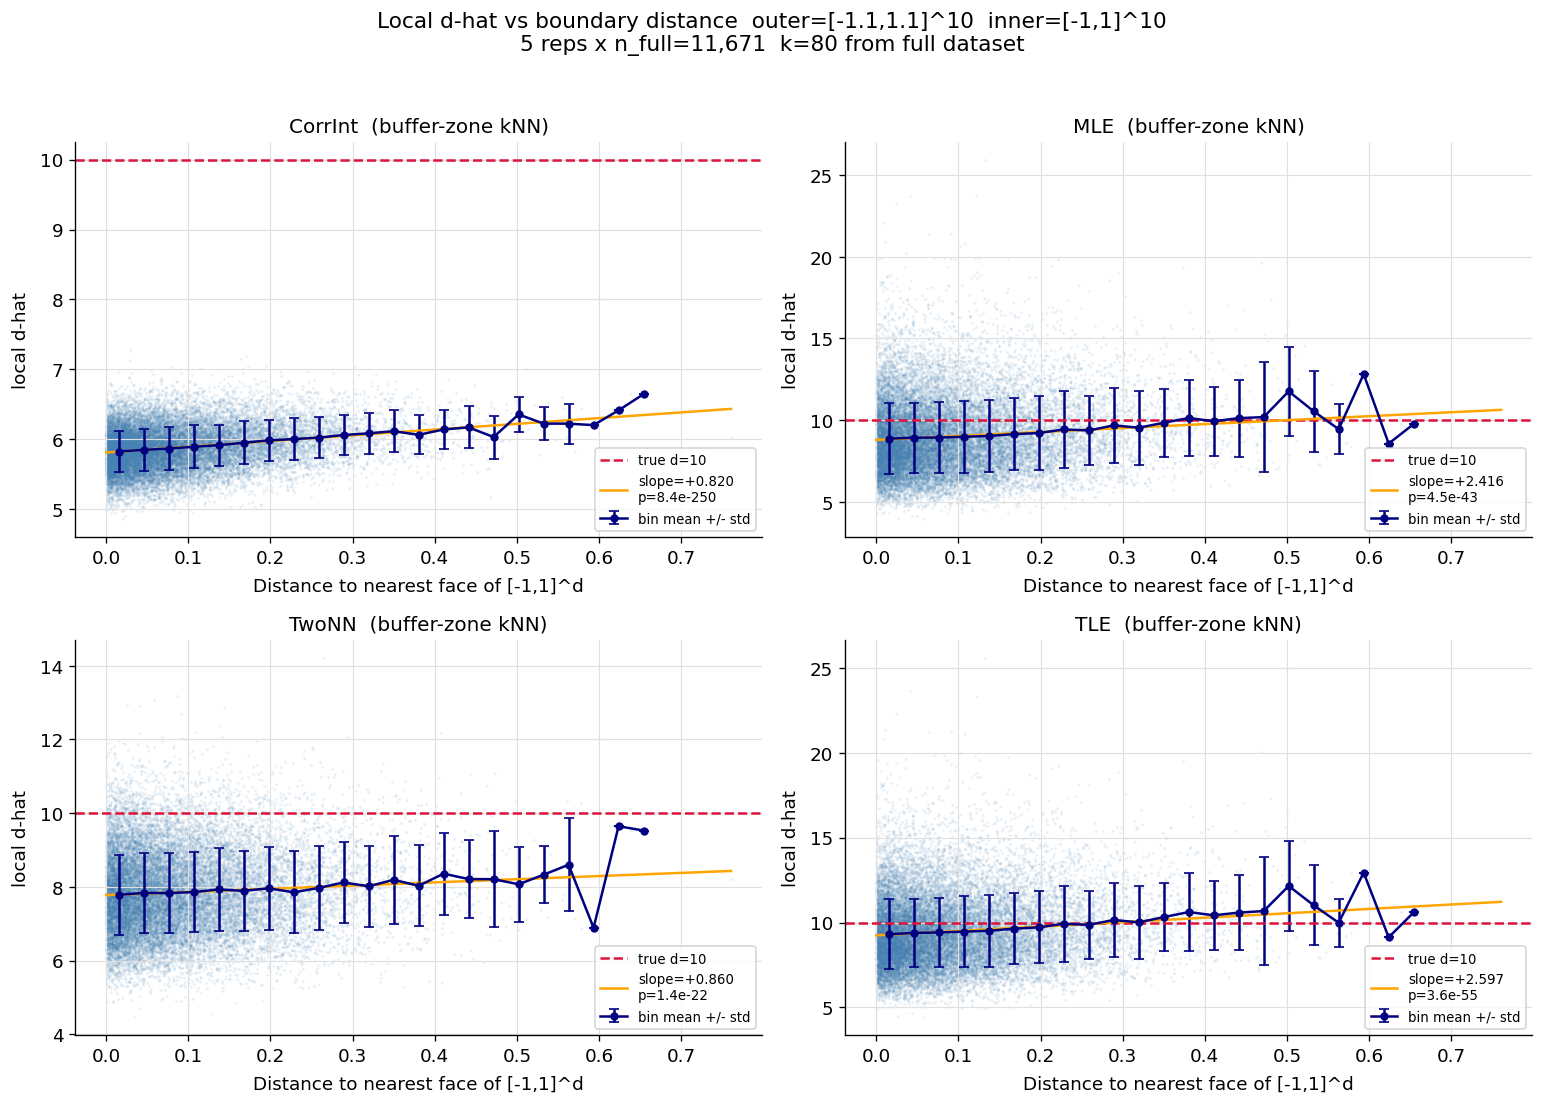

In [23]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
axes = axes.flatten()

for ax, (est_name, pw) in zip(axes, buf_local_dim.items()):
    valid = np.isfinite(pw)
    x = buf_pooled_dist[valid]
    y = pw[valid]

    slope, intercept, r, pval, se = stats.linregress(x, y)

    n_bins = 25
    bins   = np.linspace(x.min(), x.max(), n_bins + 1)
    cx     = 0.5 * (bins[:-1] + bins[1:])
    means, stds = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        sel = y[(x >= lo) & (x < hi)]
        means.append(sel.mean() if len(sel) else np.nan)
        stds.append(sel.std()   if len(sel) else np.nan)
    means, stds = np.array(means), np.array(stds)

    ax.scatter(x, y, s=1, alpha=0.07, color="steelblue", rasterized=True)
    ax.errorbar(cx, means, yerr=stds, fmt="o-", color="navy",
                ms=4, lw=1.5, capsize=3, label="bin mean +/- std")
    ax.axhline(BUF_D, color="crimson", ls="--", lw=1.5, label=f"true d={BUF_D}")
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, slope * xfit + intercept, color="orange", lw=1.5,
            label=f"slope={slope:+.3f}\np={pval:.1e}")

    ax.set_xlabel("Distance to nearest face of [-1,1]^d", labelpad=6)
    ax.set_ylabel("local d-hat", labelpad=6)
    ax.set_title(f"{est_name}  (buffer-zone kNN)", fontsize=12)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle(
    f"Local d-hat vs boundary distance  outer=[-{OUTER_LIM},{OUTER_LIM}]^{BUF_D}  inner=[-1,1]^{BUF_D}\n"
    f"{BUF_REPS} reps x n_full={N_FULL_BUF:,}  k={BUF_K} from full dataset",
    fontsize=13, y=1.02
)
fig.tight_layout()
plt.savefig("results/boundary_buffer.pdf", bbox_inches="tight")
plt.savefig("output.png", bbox_inches="tight", dpi=120)
plt.show()
